# Lab 6: Logistic Regression vs K-Nearest Neighbors

**Aim:** Implement and compare Logistic Regression and KNN classifiers on the UCI Breast Cancer Wisconsin (Diagnostic) dataset using standard classification metrics.

**Dataset:** [UCI Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) — 569 observations, 30 real-valued features, and a binary diagnosis (`M` = malignant, `B` = benign).

**Objectives:** Load and explore the data, check data quality, preprocess the features, train both models, evaluate them, and recommend the better classifier.

## 1. Import libraries

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 2. Download and load the dataset

The notebook reads `wdbc.data` directly from the UCI repository. A bundled Scikit-learn copy of the same dataset is used only as an offline fallback.

In [2]:
feature_stems = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry",
    "fractal_dimension"
]
feature_names = (
    [f"{name}_mean" for name in feature_stems]
    + [f"{name}_se" for name in feature_stems]
    + [f"{name}_worst" for name in feature_stems]
)
columns = ["id", "diagnosis"] + feature_names
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

try:
    df = pd.read_csv(uci_url, header=None, names=columns)
    data_source = "UCI repository (downloaded directly)"
except Exception:
    from sklearn.datasets import load_breast_cancer
    bunch = load_breast_cancer(as_frame=True)
    df = bunch.frame.rename(columns={"target": "diagnosis"})
    df["diagnosis"] = df["diagnosis"].map({0: "M", 1: "B"})
    df.insert(0, "id", np.arange(1, len(df) + 1))
    data_source = "Scikit-learn offline copy"

print("Source:", data_source)
print("Dataset shape:", df.shape)
df.head()

Source: UCI repository (downloaded directly)
Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory data analysis and data quality

In [3]:
print("Data types:")
print(df.dtypes.value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique IDs:", df["id"].nunique(), "of", len(df))
print("\nDiagnosis counts:")
display(df["diagnosis"].value_counts().rename(index={"B": "Benign", "M": "Malignant"}))

Data types:
float64    30
int64       1
object      1
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0
Unique IDs: 569 of 569

Diagnosis counts:


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

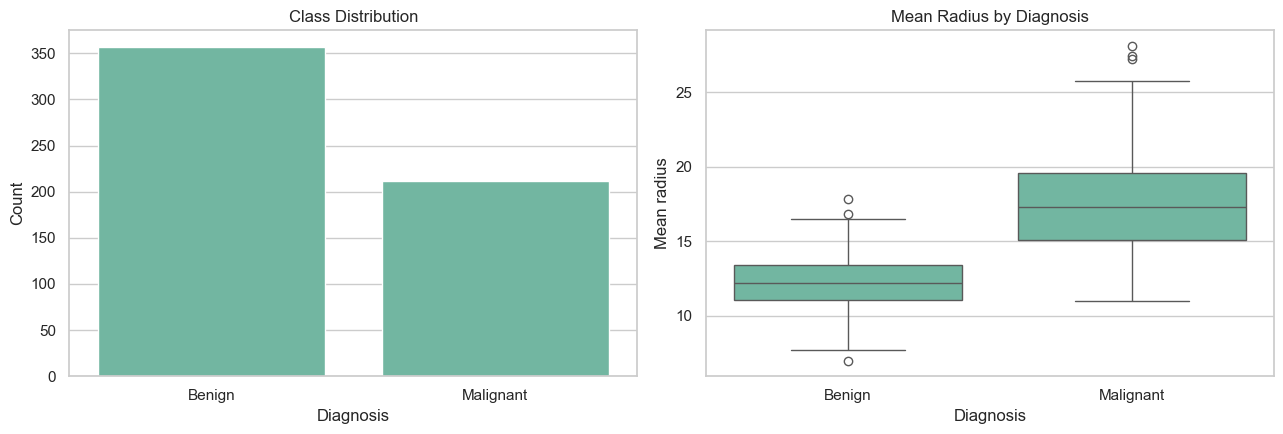

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave_points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="diagnosis", order=["B", "M"], ax=axes[0])
axes[0].set(title="Class Distribution", xlabel="Diagnosis", ylabel="Count")
axes[0].set_xticklabels(["Benign", "Malignant"])

sns.boxplot(data=df, x="diagnosis", y="radius_mean", order=["B", "M"], ax=axes[1])
axes[1].set(title="Mean Radius by Diagnosis", xlabel="Diagnosis", ylabel="Mean radius")
axes[1].set_xticklabels(["Benign", "Malignant"])

plt.tight_layout()
plt.show()

df.drop(columns=["id"]).describe().T.round(3).head(10)

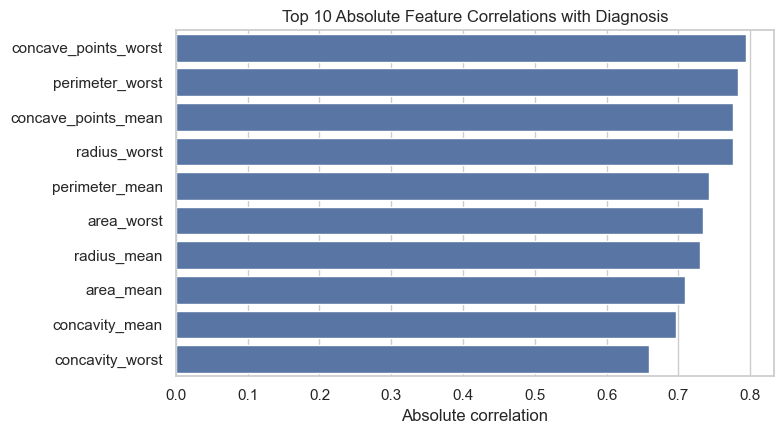

,absolute_correlation
concave_points_worst,0.794
perimeter_worst,0.783
concave_points_mean,0.777
radius_worst,0.776
perimeter_mean,0.743
area_worst,0.734
radius_mean,0.730
area_mean,0.709
concavity_mean,0.696
concavity_worst,0.660


In [5]:
# Features most strongly associated with malignant diagnosis
eda_numeric = df.drop(columns=["id"]).copy()
eda_numeric["diagnosis"] = eda_numeric["diagnosis"].map({"B": 0, "M": 1})
target_corr = (
    eda_numeric.corr(numeric_only=True)["diagnosis"]
    .drop("diagnosis").abs().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=target_corr.values, y=target_corr.index, color="#4C72B0")
plt.title("Top 10 Absolute Feature Correlations with Diagnosis")
plt.xlabel("Absolute correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()
target_corr.to_frame("absolute_correlation").round(3)

The identifier is not a predictive measurement and is removed. Diagnosis is encoded as malignant = 1 (positive class) and benign = 0. Scaling is performed inside each pipeline after the split, preventing test-data leakage and ensuring distance-based KNN is not dominated by large-scale features.

## 4. Prepare and split the data

In [6]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set : {X_test.shape[0]} rows")
print("Training class proportions:")
display(y_train.value_counts(normalize=True).sort_index().rename(index={0: "Benign", 1: "Malignant"}).round(3))

Training set: 455 rows
Testing set : 114 rows
Training class proportions:


diagnosis
Benign       0.626
Malignant    0.374
Name: proportion, dtype: float64

## 5. Sigmoid function used by Logistic Regression

Logistic Regression converts the linear score $z$ into a probability between 0 and 1 using

$$\sigma(z)=\frac{1}{1+e^{-z}}.$$

With the default decision threshold, probabilities of at least 0.5 are classified as malignant (class 1).

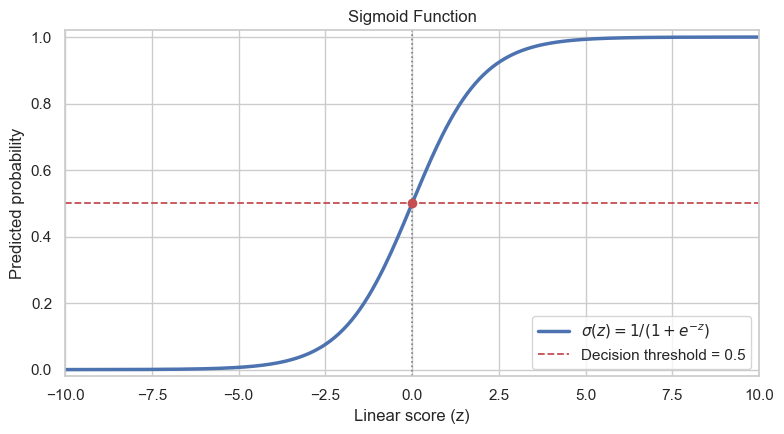

In [7]:
z = np.linspace(-10, 10, 500)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, sigmoid, color="#4C72B0", linewidth=2.5, label=r"$\sigma(z)=1/(1+e^{-z})$")
ax.axhline(0.5, color="#C44E52", linestyle="--", linewidth=1.3, label="Decision threshold = 0.5")
ax.axvline(0, color="gray", linestyle=":", linewidth=1.2)
ax.scatter([0], [0.5], color="#C44E52", zorder=3)
ax.set(title="Sigmoid Function", xlabel="Linear score (z)", ylabel="Predicted probability")
ax.set_xlim(-10, 10)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Train Logistic Regression and KNN

In [8]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5)),
    ]),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"Trained: {name}")

Trained: Logistic Regression


Trained: KNN (k=5)


## 7. Evaluate and compare the classifiers

Precision, recall, and F1 score treat **malignant** cases as the positive class.

In [9]:
results = []
for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    })

comparison = pd.DataFrame(results).set_index("Model")
comparison_table = comparison.reset_index()
display(
    comparison_table.style
    .hide(axis="index")
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
    })
    .set_properties(subset=["Model"], **{"text-align": "left"})
)

Model,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.965,0.975,0.929,0.951
KNN (k=5),0.956,0.974,0.905,0.938


### Graphical comparison of the four evaluation metrics

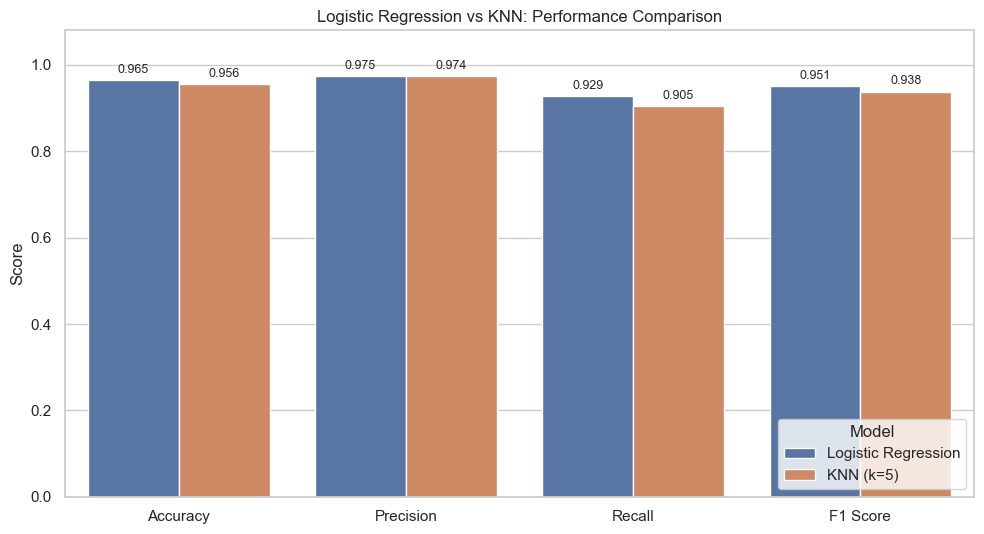

In [10]:
metrics_long = comparison_table.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#4C72B0", "#DD8452"],
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Logistic Regression vs KNN: Performance Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.legend(title="Model", loc="lower right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

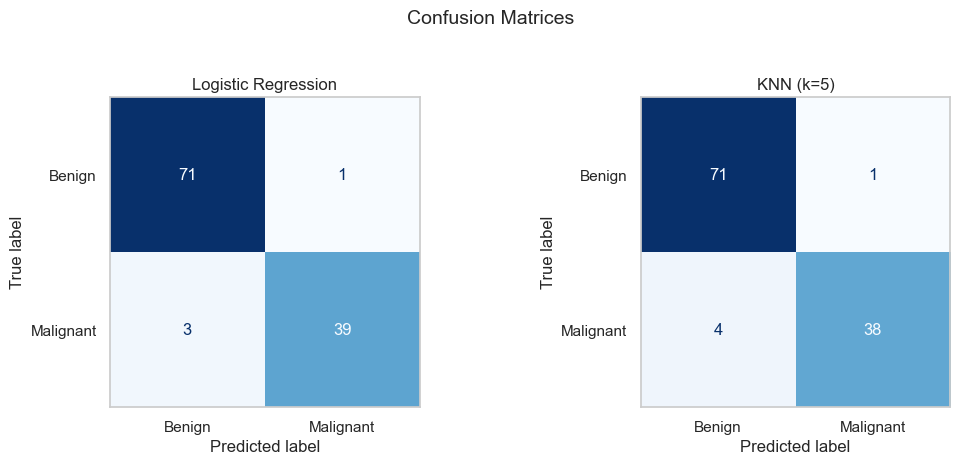

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["Benign", "Malignant"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    ax.grid(False)
plt.suptitle("Confusion Matrices", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
for name, y_pred in predictions.items():
    print(f"\n{name}\n" + "-" * len(name))
    print(classification_report(
        y_test, y_pred,
        target_names=["Benign", "Malignant"],
        digits=4,
        zero_division=0,
    ))


Logistic Regression
-------------------
              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114


KNN (k=5)
---------
              precision    recall  f1-score   support

      Benign     0.9467    0.9861    0.9660        72
   Malignant     0.9744    0.9048    0.9383        42

    accuracy                         0.9561       114
   macro avg     0.9605    0.9454    0.9521       114
weighted avg     0.9569    0.9561    0.9558       114



## 8. Interpretation and conclusion

Logistic Regression performs better overall on this test split (accuracy=0.965, F1=0.951). It is therefore the recommended classifier for this experiment. For medical screening, recall should also be prioritized because a false negative misses a malignant case.